# PZ data challenge: task set 1

**Task set 1: representative training.** The training and test sets are drawn from the same distribution (i < 23.5).

This notebook runs all four configurations of the task set (cardinal and flagship, 1yr and 10yr). For each one it:

1. trains the CNN ensemble on the training file, holding out `VAL_FRAC` of it for evaluation (test redshifts are hidden);
2. scores the held-out objects with the challenge's metrics. The point metrics (bias, scatter, |Δz| > 0.2 rate) match RAIL's biweight statistics, and the PIT metrics come from `qp.metrics.pit.PIT`, as in the challenge evaluator;
3. writes the submission files under their official names into `OUT_DIR`, shared by all four task-set notebooks:
   - the test-set p(z) (subtask 1), checked with the challenge's own format check;
   - the trained ensemble as a single `.pkl` (subtask 2), via `znn.save_ensemble_file`.

Every p(z), on held-out and test objects, comes from `znn.ensemble_predict_resampled`. It redraws the photometry `N_SAMPLES` times from the catalogue's `_err` columns, runs every ensemble member on every draw, and takes a Gaussian with the mean and spread of those predictions. The width therefore includes both the spread between members and the photometric errors. `N_SAMPLES = 50` was enough for the results to converge on Cardinal Y1 (`CNN_photoz-ensemble-cardinal_noise_realizations.ipynb`).

Run this from the repo root with the `qp` conda env as the kernel. The filter curves are the ones shipped with RAIL, which `pz_data_challenge` installs.

## Configuration

In [6]:
from rail.utils.path_utils import find_rail_file

import znn  # run from the repo root so this picks up the local source

TASKSET = 1
SIMS = ["cardinal", "flagship"]
SCENARIOS = ["1yr", "10yr"]

DATA_DIR = "../pz_data_challenge/scripts/public"
# Training starting point: "popcosmos" (the pre-training shipped with znn) or None (from scratch). Each choice
# writes to its own directory, so runs with and without pre-training never overwrite each other.
PRETRAINING = "popcosmos"
OUT_DIR = "outputs/znn" if PRETRAINING is None else f"outputs/znn_pretrained_{PRETRAINING}"  # submission files for all task sets; the contents of the submission tarball

# Filter curves shipped with RAIL; the challenge's catalogs.yaml ("cardinal_roman_rubin") maps the
# catalogue columns to these DC2LSST_* and roman_* filters
FILTER_DIR = find_rail_file("examples_data/estimation_data/data/FILTER")

# band -> (catalogue magnitude column, filter curve file), ordered by wavelength
BANDS = {
    "u": ("mag_u_lsst", f"{FILTER_DIR}/DC2LSST_u.res"),
    "g": ("mag_g_lsst", f"{FILTER_DIR}/DC2LSST_g.res"),
    "r": ("mag_r_lsst", f"{FILTER_DIR}/DC2LSST_r.res"),
    "i": ("mag_i_lsst", f"{FILTER_DIR}/DC2LSST_i.res"),
    "z": ("mag_z_lsst", f"{FILTER_DIR}/DC2LSST_z.res"),
    "y": ("mag_y_lsst", f"{FILTER_DIR}/DC2LSST_y.res"),
    "Y": ("mag_Y_roman", f"{FILTER_DIR}/roman_Y106.res"),
    "J": ("mag_J_roman", f"{FILTER_DIR}/roman_J129.res"),
    "H": ("mag_H_roman", f"{FILTER_DIR}/roman_H158.res"),
}
REF_BAND = "i"  # magnitudes are normalized by this band
FEATURE_CONFIG = znn.DEFAULT_FEATURE_CONFIG

# Photometric error propagation at prediction time: magnitude column -> its error column
ERRORS = {col: f"{col}_err" for col, _ in BANDS.values()}
N_SAMPLES = 50  # noise draws per object; converged by 50 on Cardinal Y1
NOISE_SEED = 42

VAL_FRAC = 0.2  # fraction of the training set held out for evaluation
N_SPLITS = 5  # ensemble members (K-fold); 10 in the full setup
EPOCHS = 100  # max epochs per member (early stopping usually ends sooner)
SEED = 42

In [7]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from qp.metrics.pit import PIT
from sklearn.model_selection import train_test_split

from pz_data_challenge import scoring, submit_utils

os.makedirs(OUT_DIR, exist_ok=True)
print("znn from", znn.__file__)

znn from /global/u2/j/jaimerz/UCL/mlpz_cnn_deepset/znn/__init__.py


## Reference redshifts and evaluation subsets

In [8]:
def reference_redshifts(train):
    """Reference redshift per training object, and the held-out subsets to score."""
    z_ref = train["redshift"].to_numpy()
    assert np.isfinite(z_ref).all()
    return z_ref, {"held-out": np.ones(len(train), dtype=bool)}

## Evaluation helpers

In [9]:
redshift_bins = np.linspace(0, 2.5, 11)
imag_bins = np.linspace(18, 25.5, 11)


def predict(trained_models, df, rng):
    """p(z) of the ensemble with the photometric errors propagated (N_SAMPLES draws per object)."""
    return znn.ensemble_predict_resampled(
        trained_models, df, ERRORS, N_SAMPLES, rng, BANDS, REF_BAND, FEATURE_CONFIG, ids=df["object_id"].to_numpy()
    )


def evaluate(trained_models, df_eval, z_eval, rng, title):
    """Point and PIT metrics of the ensemble on one set of objects."""
    pz = predict(trained_models, df_eval, rng)
    mag_i = df_eval["mag_i_lsst"].to_numpy()
    z_point = np.squeeze(pz.ancil["zmode"])

    point_stats, redshift_stats, imag_stats = znn.get_all_stats(
        z_eval, z_point, mag_i, save=False, redshift_bins=redshift_bins, imag_bins=imag_bins
    )
    znn.plot_stats(point_stats, redshift_stats, imag_stats, z_eval, z_point, redshift_bins, imag_bins, mag_i)
    plt.suptitle(f"{title} ({len(z_eval)} objects)", y=1.02)
    plt.show()

    mean, _, std, _, abs_outlier_rate = point_stats
    pit = PIT(pz, z_eval)
    values = {
        "mean": mean,
        "std": std,
        "abs_outlier_rate": abs_outlier_rate,
        "ks": pit.evaluate_PIT_KS().statistic,
        "CvM": pit.evaluate_PIT_CvM().statistic,
        "ksamp": pit.evaluate_PIT_anderson_ksamp().statistic,
        # qp derives this from a spline fit to the PIT quantiles; it breaks down (huge values) when PIT
        # piles up at 0 or 1. The challenge evaluator uses the same call.
        "outlier": pit.evaluate_PIT_outlier_rate(),
        "pit_outlier_direct": np.mean((pit.pit_samps < 0.0001) | (pit.pit_samps > 0.9999)),
    }
    return values


def tier_points(values):
    """Points against the challenge scoring tiers: one per nested range a metric falls inside."""
    return {name: sum(lo <= float(values[name]) <= hi for lo, hi in ranges) for name, ranges in scoring.metric_dict.items()}

## Run all configurations

For each configuration: train on the fit split, score the held-out subsets, then write the test-set p(z) and the model file. The model used for the submission files is the one trained on the fit split.


========== task set 1: cardinal_1yr ==========


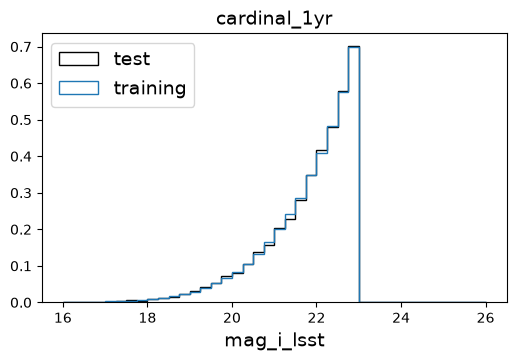

I0000 00:00:1791447757.587195  874957 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79189 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:03:00.0, compute capability: 8.0
I0000 00:00:1791447757.591093  874957 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 79189 MB memory:  -> device: 1, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:41:00.0, compute capability: 8.0
I0000 00:00:1791447757.594949  874957 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 79189 MB memory:  -> device: 2, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:82:00.0, compute capability: 8.0
I0000 00:00:1791447757.598638  874957 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 79189 MB memory:  -> device: 3, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:c1:00.0, compute capability: 8.0



--- Fold 1/5 ---
Epoch 1/100


I0000 00:00:1791447761.684290  877159 service.cc:153] XLA service 0x7fdc14034c40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1791447761.684310  877159 service.cc:161]   StreamExecutor [0]: NVIDIA A100-SXM4-80GB, Compute Capability 8.0 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.27.0)
I0000 00:00:1791447761.684320  877159 service.cc:161]   StreamExecutor [1]: NVIDIA A100-SXM4-80GB, Compute Capability 8.0 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.27.0)
I0000 00:00:1791447761.684323  877159 service.cc:161]   StreamExecutor [2]: NVIDIA A100-SXM4-80GB, Compute Capability 8.0 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.27.0)
I0000 00:00:1791447761.684326  877159 service.cc:161]   StreamExecutor [3]: NVIDIA A100-SXM4-80GB, Compute Capability 8.0 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.27.0)
I0000 00:00:1791447761.727350  877159 dump_mlir_util.cc:269] disabling MLIR crash repro

250/250 - 15s - 59ms/step - loss: 0.0014 - val_loss: 3.2228e-04 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 5.7735e-04 - val_loss: 2.3416e-04 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 4.2934e-04 - val_loss: 2.1792e-04 - learning_rate: 0.0010
Epoch 4/100
250/250 - 1s - 3ms/step - loss: 3.8258e-04 - val_loss: 2.4808e-04 - learning_rate: 0.0010
Epoch 5/100
250/250 - 1s - 3ms/step - loss: 3.7008e-04 - val_loss: 1.9825e-04 - learning_rate: 0.0010
Epoch 6/100

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 3.7262e-04 - val_loss: 1.8550e-04 - learning_rate: 0.0010
Epoch 7/100
250/250 - 1s - 3ms/step - loss: 3.3030e-04 - val_loss: 1.7490e-04 - learning_rate: 5.0000e-04
Epoch 8/100
250/250 - 1s - 3ms/step - loss: 3.1912e-04 - val_loss: 1.9034e-04 - learning_rate: 5.0000e-04
Epoch 9/100

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
250/250 - 1s - 3ms/step 

I0000 00:00:1791447794.465155  877161 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_34199__.37


...

250/250 - 4s - 18ms/step - loss: 0.0012 - val_loss: 2.5704e-04 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 5.0318e-04 - val_loss: 2.1529e-04 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 4.3142e-04 - val_loss: 2.1305e-04 - learning_rate: 0.0010
Epoch 4/100

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 4.0068e-04 - val_loss: 1.9128e-04 - learning_rate: 0.0010
Epoch 5/100
250/250 - 1s - 3ms/step - loss: 3.8273e-04 - val_loss: 1.7376e-04 - learning_rate: 5.0000e-04
Epoch 6/100
250/250 - 1s - 3ms/step - loss: 3.5915e-04 - val_loss: 1.9124e-04 - learning_rate: 5.0000e-04
Epoch 7/100

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
250/250 - 1s - 3ms/step - loss: 3.5193e-04 - val_loss: 1.7443e-04 - learning_rate: 5.0000e-04
Epoch 8/100
250/250 - 1s - 3ms/step - loss: 3.2776e-04 - val_loss: 1.6312e-04 - learning_rate: 2.5000e-04
Epoch 9/100
250/250 - 1s - 3m

I0000 00:00:1791447845.651350  877160 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_101946__.37


250/250 - 5s - 18ms/step - loss: 0.0014 - val_loss: 3.3225e-04 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 6.5752e-04 - val_loss: 2.8978e-04 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 4.6818e-04 - val_loss: 2.5493e-04 - learning_rate: 0.0010
Epoch 4/100

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 4.0094e-04 - val_loss: 2.4208e-04 - learning_rate: 0.0010
Epoch 5/100
250/250 - 1s - 3ms/step - loss: 3.5407e-04 - val_loss: 2.0190e-04 - learning_rate: 5.0000e-04
Epoch 6/100
250/250 - 1s - 3ms/step - loss: 3.4622e-04 - val_loss: 1.9719e-04 - learning_rate: 5.0000e-04
Epoch 7/100
250/250 - 1s - 3ms/step - loss: 3.2819e-04 - val_loss: 2.0553e-04 - learning_rate: 5.0000e-04
Epoch 8/100

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
250/250 - 1s - 3ms/step - loss: 3.2349e-04 - val_loss: 2.4398e-04 - learning_rate: 5.0000e-04
Epoch 9/100
250/250 - 1s - 3m

I0000 00:00:1791447870.447881  877158 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_134409__.37


250/250 - 4s - 18ms/step - loss: 0.0013 - val_loss: 3.2744e-04 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 5.4126e-04 - val_loss: 2.4933e-04 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 3.9954e-04 - val_loss: 2.4614e-04 - learning_rate: 0.0010
Epoch 4/100

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 3.6184e-04 - val_loss: 2.4845e-04 - learning_rate: 0.0010
Epoch 5/100
250/250 - 1s - 3ms/step - loss: 3.3084e-04 - val_loss: 2.3076e-04 - learning_rate: 5.0000e-04
Epoch 6/100
250/250 - 1s - 3ms/step - loss: 3.1642e-04 - val_loss: 2.4085e-04 - learning_rate: 5.0000e-04
Epoch 7/100
250/250 - 1s - 3ms/step - loss: 3.1359e-04 - val_loss: 2.0186e-04 - learning_rate: 5.0000e-04
Epoch 8/100
250/250 - 1s - 3ms/step - loss: 3.0454e-04 - val_loss: 2.5956e-04 - learning_rate: 5.0000e-04
Epoch 9/100
250/250 - 1s - 3ms/step - loss: 3.0299e-04 - val_loss: 2.0842e-04 - learning_rate: 5.0000e-04


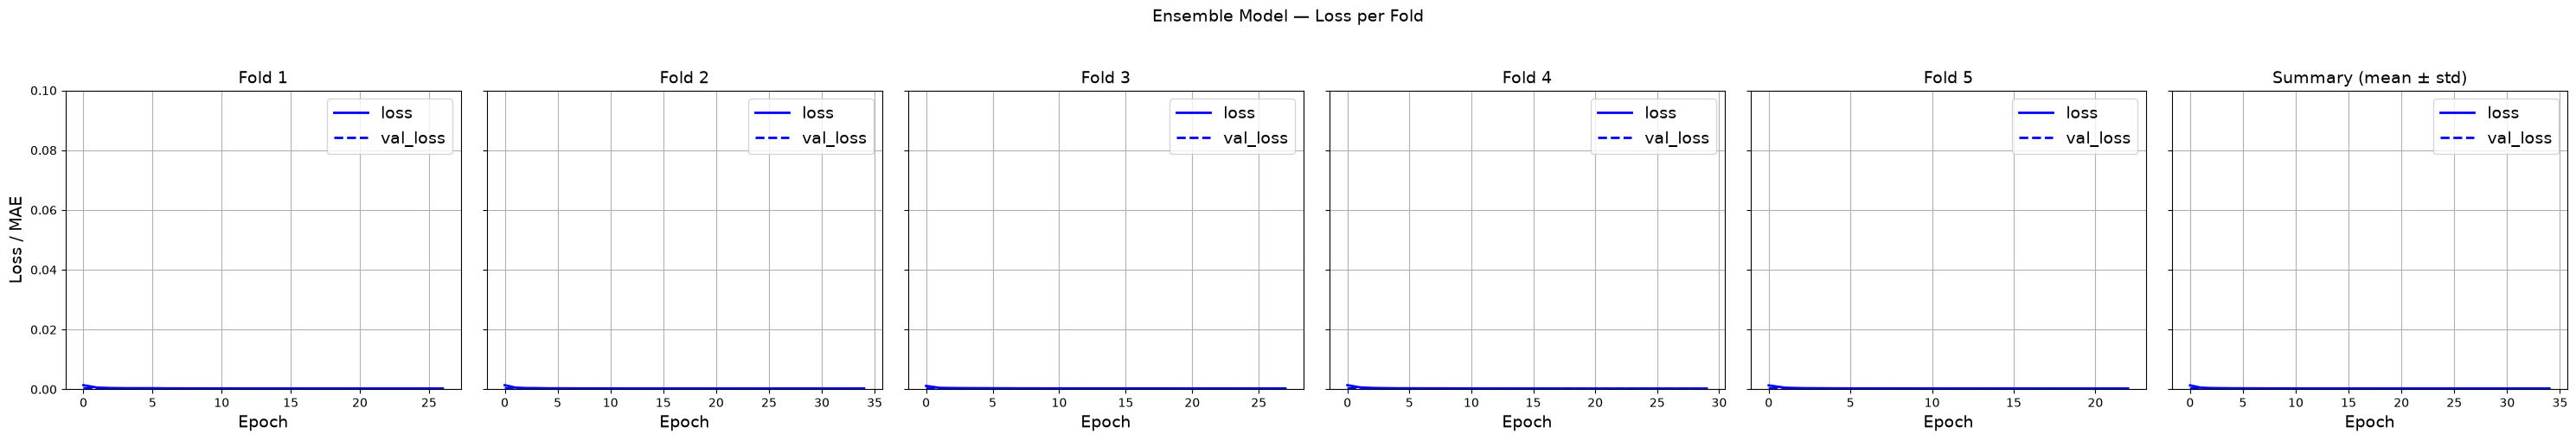

/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3862: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/global/u2/j/jaimerz/UCL/mlpz_cnn_deepset

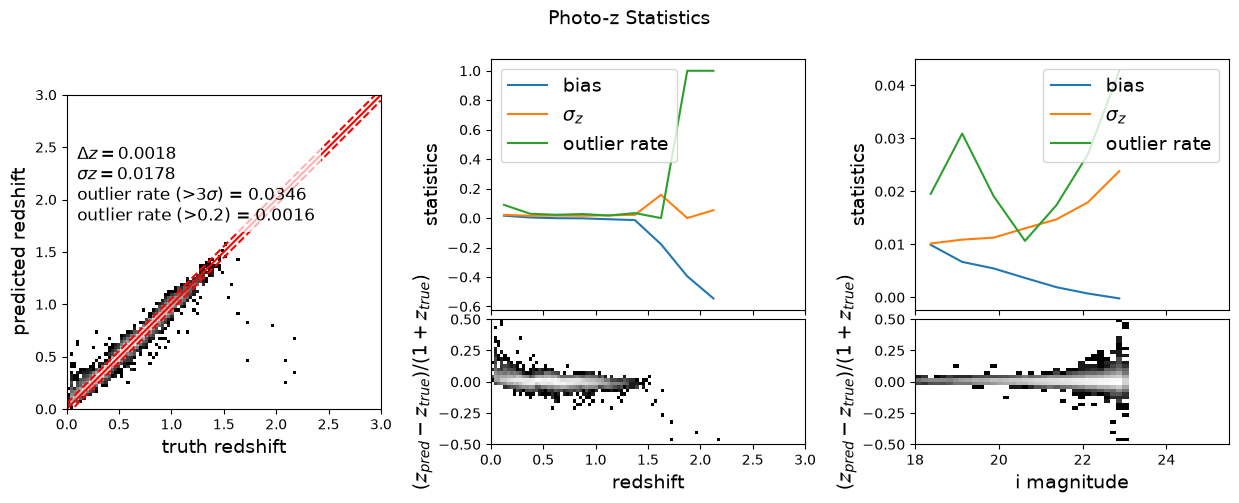

<Figure size 640x480 with 0 Axes>

/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/qp/metrics/array_metrics.py:27: UserWarning: Parameter `variant` has been introduced to replace `midrank`; `midrank` will be removed in SciPy 1.19.0. Specify `variant` to silence this warning. Note that the returned object will no longer be unpackable as a tuple, and `critical_values` will be omitted.
  return stats.anderson_ksamp([p_random_variables, q_random_variables], **kwargs)
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/qp/metrics/array_metrics.py:27: UserWarning: p-value floored: true value smaller than 0.001. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  return stats.anderson_ksamp([p_random_variables, q_random_variables], **kwargs)


outputs/znn_pretrained_popcosmos/pz_challenge_taskset_1_cardinal_pz_estimate_1yr.hdf5 checks passed: [1, 2, 3, 4, 5, 6, 7]

========== task set 1: cardinal_10yr ==========


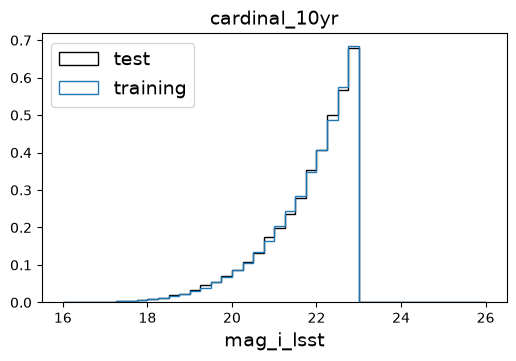


--- Fold 1/5 ---
Epoch 1/100


I0000 00:00:1791447982.635845  877160 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_212815__.37


250/250 - 5s - 18ms/step - loss: 0.0012 - val_loss: 2.7016e-04 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 4.3007e-04 - val_loss: 1.5329e-04 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 3.0083e-04 - val_loss: 1.0204e-04 - learning_rate: 0.0010
Epoch 4/100
250/250 - 1s - 3ms/step - loss: 2.8556e-04 - val_loss: 1.2417e-04 - learning_rate: 0.0010
Epoch 5/100

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 2.6932e-04 - val_loss: 1.1988e-04 - learning_rate: 0.0010
Epoch 6/100
250/250 - 1s - 3ms/step - loss: 2.4781e-04 - val_loss: 1.0635e-04 - learning_rate: 5.0000e-04
Epoch 7/100
250/250 - 1s - 3ms/step - loss: 2.3884e-04 - val_loss: 8.6718e-05 - learning_rate: 5.0000e-04
Epoch 8/100

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
250/250 - 1s - 3ms/step - loss: 2.3511e-04 - val_loss: 9.7572e-05 - learning_rate: 5.0000e-04
Epoch 9/100
250/250 - 1s - 3ms/st

I0000 00:00:1791448003.407851  877157 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_239346__.37


250/250 - 4s - 18ms/step - loss: 0.0011 - val_loss: 1.8175e-04 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 3.8596e-04 - val_loss: 1.9037e-04 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 2.9383e-04 - val_loss: 1.4330e-04 - learning_rate: 0.0010
Epoch 4/100

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 2.5883e-04 - val_loss: 1.2234e-04 - learning_rate: 0.0010
Epoch 5/100
250/250 - 1s - 3ms/step - loss: 2.3154e-04 - val_loss: 9.6293e-05 - learning_rate: 5.0000e-04
Epoch 6/100
250/250 - 1s - 3ms/step - loss: 2.3329e-04 - val_loss: 8.5841e-05 - learning_rate: 5.0000e-04
Epoch 7/100

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
250/250 - 1s - 3ms/step - loss: 2.2555e-04 - val_loss: 9.0332e-05 - learning_rate: 5.0000e-04
Epoch 8/100
250/250 - 1s - 3ms/step - loss: 2.2265e-04 - val_loss: 7.7478e-05 - learning_rate: 2.5000e-04
Epoch 9/100
250/250 - 1s - 3m

...

250/250 - 5s - 19ms/step - loss: 9.1587e-04 - val_loss: 1.5529e-04 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 3.5875e-04 - val_loss: 1.3649e-04 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 3.0247e-04 - val_loss: 8.8992e-05 - learning_rate: 0.0010
Epoch 4/100

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 2.8884e-04 - val_loss: 1.2891e-04 - learning_rate: 0.0010
Epoch 5/100
250/250 - 1s - 3ms/step - loss: 2.5992e-04 - val_loss: 6.5865e-05 - learning_rate: 5.0000e-04
Epoch 6/100
250/250 - 1s - 3ms/step - loss: 2.5070e-04 - val_loss: 6.4539e-05 - learning_rate: 5.0000e-04
Epoch 7/100

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
250/250 - 1s - 3ms/step - loss: 2.4730e-04 - val_loss: 8.0265e-05 - learning_rate: 5.0000e-04
Epoch 8/100
250/250 - 1s - 3ms/step - loss: 2.4887e-04 - val_loss: 7.1115e-05 - learning_rate: 2.5000e-04
Epoch 9/100
250/250 - 1s 

I0000 00:00:1791448047.491414  877160 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_296289__.37


250/250 - 5s - 18ms/step - loss: 0.0011 - val_loss: 1.4947e-04 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 4.5268e-04 - val_loss: 1.3057e-04 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 2.8399e-04 - val_loss: 1.3310e-04 - learning_rate: 0.0010
Epoch 4/100

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 2.6371e-04 - val_loss: 1.2564e-04 - learning_rate: 0.0010
Epoch 5/100
250/250 - 1s - 3ms/step - loss: 2.1851e-04 - val_loss: 7.6495e-05 - learning_rate: 5.0000e-04
Epoch 6/100
250/250 - 1s - 3ms/step - loss: 2.1596e-04 - val_loss: 1.0584e-04 - learning_rate: 5.0000e-04
Epoch 7/100

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
250/250 - 1s - 3ms/step - loss: 2.0535e-04 - val_loss: 9.8381e-05 - learning_rate: 5.0000e-04
Epoch 8/100
250/250 - 1s - 3ms/step - loss: 2.0099e-04 - val_loss: 8.4086e-05 - learning_rate: 2.5000e-04
Epoch 9/100
250/250 - 1s - 3m

I0000 00:00:1791448063.533863  877161 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_315959__.37


250/250 - 5s - 19ms/step - loss: 0.0011 - val_loss: 1.3850e-04 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 4.0038e-04 - val_loss: 1.4315e-04 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 3.0490e-04 - val_loss: 9.1084e-05 - learning_rate: 0.0010
Epoch 4/100

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 2.7485e-04 - val_loss: 8.8827e-05 - learning_rate: 0.0010
Epoch 5/100
250/250 - 1s - 3ms/step - loss: 2.4236e-04 - val_loss: 8.0563e-05 - learning_rate: 5.0000e-04
Epoch 6/100
250/250 - 1s - 3ms/step - loss: 2.3884e-04 - val_loss: 7.5543e-05 - learning_rate: 5.0000e-04
Epoch 7/100

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
250/250 - 1s - 3ms/step - loss: 2.2559e-04 - val_loss: 5.9716e-05 - learning_rate: 5.0000e-04
Epoch 8/100
250/250 - 1s - 3ms/step - loss: 2.1798e-04 - val_loss: 6.1912e-05 - learning_rate: 2.5000e-04
Epoch 9/100
250/250 - 1s - 3m

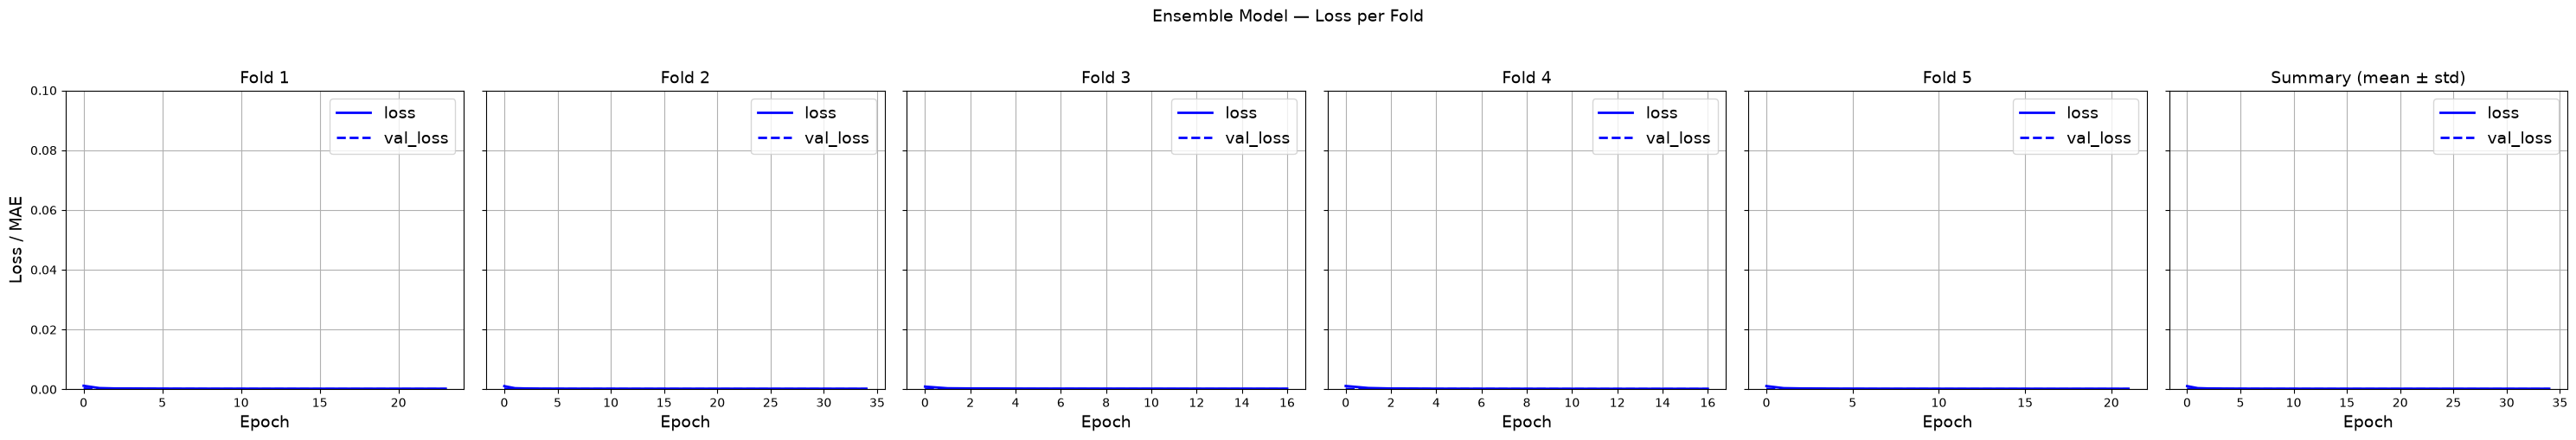

/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3862: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/global/u2/j/jaimerz/UCL/mlpz_cnn_deepset

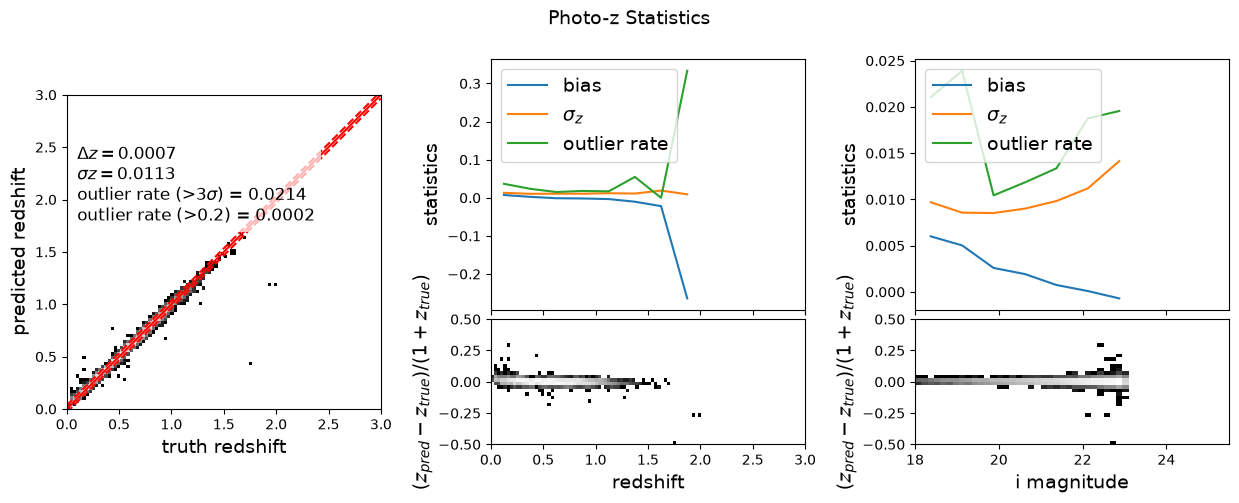

<Figure size 640x480 with 0 Axes>

/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/qp/metrics/array_metrics.py:27: UserWarning: Parameter `variant` has been introduced to replace `midrank`; `midrank` will be removed in SciPy 1.19.0. Specify `variant` to silence this warning. Note that the returned object will no longer be unpackable as a tuple, and `critical_values` will be omitted.
  return stats.anderson_ksamp([p_random_variables, q_random_variables], **kwargs)
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/qp/metrics/array_metrics.py:27: UserWarning: p-value floored: true value smaller than 0.001. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  return stats.anderson_ksamp([p_random_variables, q_random_variables], **kwargs)


outputs/znn_pretrained_popcosmos/pz_challenge_taskset_1_cardinal_pz_estimate_10yr.hdf5 checks passed: [1, 2, 3, 4, 5, 6, 7]

========== task set 1: flagship_1yr ==========


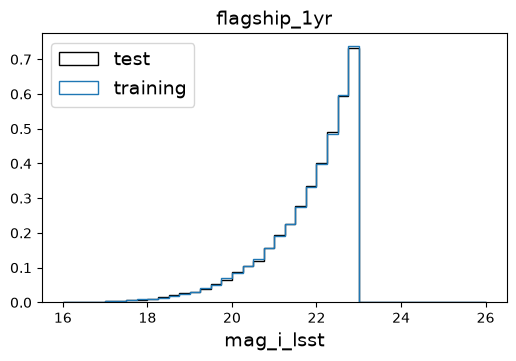


--- Fold 1/5 ---
Epoch 1/100


I0000 00:00:1791448171.982375  877158 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_393343__.37


250/250 - 5s - 18ms/step - loss: 0.0014 - val_loss: 2.8388e-04 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 6.7185e-04 - val_loss: 2.3755e-04 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 5.4220e-04 - val_loss: 2.2770e-04 - learning_rate: 0.0010
Epoch 4/100

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 5.1355e-04 - val_loss: 2.1197e-04 - learning_rate: 0.0010
Epoch 5/100
250/250 - 1s - 3ms/step - loss: 4.8038e-04 - val_loss: 2.1885e-04 - learning_rate: 5.0000e-04
Epoch 6/100
250/250 - 1s - 3ms/step - loss: 4.7227e-04 - val_loss: 2.0359e-04 - learning_rate: 5.0000e-04
Epoch 7/100

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
250/250 - 1s - 3ms/step - loss: 4.6938e-04 - val_loss: 1.9167e-04 - learning_rate: 5.0000e-04
Epoch 8/100
250/250 - 1s - 3ms/step - loss: 4.5104e-04 - val_loss: 1.8320e-04 - learning_rate: 2.5000e-04
Epoch 9/100
250/250 - 1s - 3m

I0000 00:00:1791448190.242902  877158 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_416059__.37


250/250 - 5s - 18ms/step - loss: 0.0014 - val_loss: 3.0752e-04 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 6.5416e-04 - val_loss: 2.8995e-04 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 5.3730e-04 - val_loss: 2.4795e-04 - learning_rate: 0.0010
Epoch 4/100

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 4.9273e-04 - val_loss: 2.7216e-04 - learning_rate: 0.0010
Epoch 5/100
250/250 - 1s - 3ms/step - loss: 4.6861e-04 - val_loss: 1.9508e-04 - learning_rate: 5.0000e-04
Epoch 6/100
250/250 - 1s - 3ms/step - loss: 4.5750e-04 - val_loss: 1.8540e-04 - learning_rate: 5.0000e-04
Epoch 7/100
250/250 - 1s - 3ms/step - loss: 4.5316e-04 - val_loss: 1.8952e-04 - learning_rate: 5.0000e-04
Epoch 8/100

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
250/250 - 1s - 3ms/step - loss: 4.4265e-04 - val_loss: 1.8613e-04 - learning_rate: 5.0000e-04
Epoch 9/100
250/250 - 1s - 3m

...

250/250 - 5s - 19ms/step - loss: 0.0012 - val_loss: 3.5353e-04 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 6.0921e-04 - val_loss: 3.8402e-04 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 5.2540e-04 - val_loss: 2.7461e-04 - learning_rate: 0.0010
Epoch 4/100

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 4.8920e-04 - val_loss: 3.1897e-04 - learning_rate: 0.0010
Epoch 5/100
250/250 - 1s - 3ms/step - loss: 4.6742e-04 - val_loss: 2.4792e-04 - learning_rate: 5.0000e-04
Epoch 6/100
250/250 - 1s - 3ms/step - loss: 4.5728e-04 - val_loss: 2.5008e-04 - learning_rate: 5.0000e-04
Epoch 7/100
250/250 - 1s - 3ms/step - loss: 4.6667e-04 - val_loss: 2.7197e-04 - learning_rate: 5.0000e-04
Epoch 8/100

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
250/250 - 1s - 3ms/step - loss: 4.4907e-04 - val_loss: 2.4573e-04 - learning_rate: 5.0000e-04
Epoch 9/100
250/250 - 1s - 3m

I0000 00:00:1791448231.468813  877160 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_468160__.37


250/250 - 5s - 18ms/step - loss: 0.0013 - val_loss: 3.2051e-04 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 6.2374e-04 - val_loss: 2.6761e-04 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 4.8675e-04 - val_loss: 2.5731e-04 - learning_rate: 0.0010
Epoch 4/100

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 4.4909e-04 - val_loss: 2.2713e-04 - learning_rate: 0.0010
Epoch 5/100
250/250 - 1s - 3ms/step - loss: 4.1624e-04 - val_loss: 2.0790e-04 - learning_rate: 5.0000e-04
Epoch 6/100
250/250 - 1s - 3ms/step - loss: 4.1251e-04 - val_loss: 2.1791e-04 - learning_rate: 5.0000e-04
Epoch 7/100
250/250 - 1s - 3ms/step - loss: 4.0267e-04 - val_loss: 1.9455e-04 - learning_rate: 5.0000e-04
Epoch 8/100

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
250/250 - 1s - 3ms/step - loss: 4.0399e-04 - val_loss: 2.0173e-04 - learning_rate: 5.0000e-04
Epoch 9/100
250/250 - 1s - 3m

I0000 00:00:1791448253.698639  877159 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_496744__.37


250/250 - 5s - 18ms/step - loss: 0.0013 - val_loss: 2.7722e-04 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 6.2684e-04 - val_loss: 2.9064e-04 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 5.1218e-04 - val_loss: 2.7010e-04 - learning_rate: 0.0010
Epoch 4/100

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 4.9430e-04 - val_loss: 2.2455e-04 - learning_rate: 0.0010
Epoch 5/100
250/250 - 1s - 3ms/step - loss: 4.4879e-04 - val_loss: 2.1134e-04 - learning_rate: 5.0000e-04
Epoch 6/100
250/250 - 1s - 3ms/step - loss: 4.4218e-04 - val_loss: 2.0630e-04 - learning_rate: 5.0000e-04
Epoch 7/100

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
250/250 - 1s - 3ms/step - loss: 4.4449e-04 - val_loss: 1.9740e-04 - learning_rate: 5.0000e-04
Epoch 8/100
250/250 - 1s - 3ms/step - loss: 4.2396e-04 - val_loss: 1.9842e-04 - learning_rate: 2.5000e-04
Epoch 9/100
250/250 - 1s - 3m

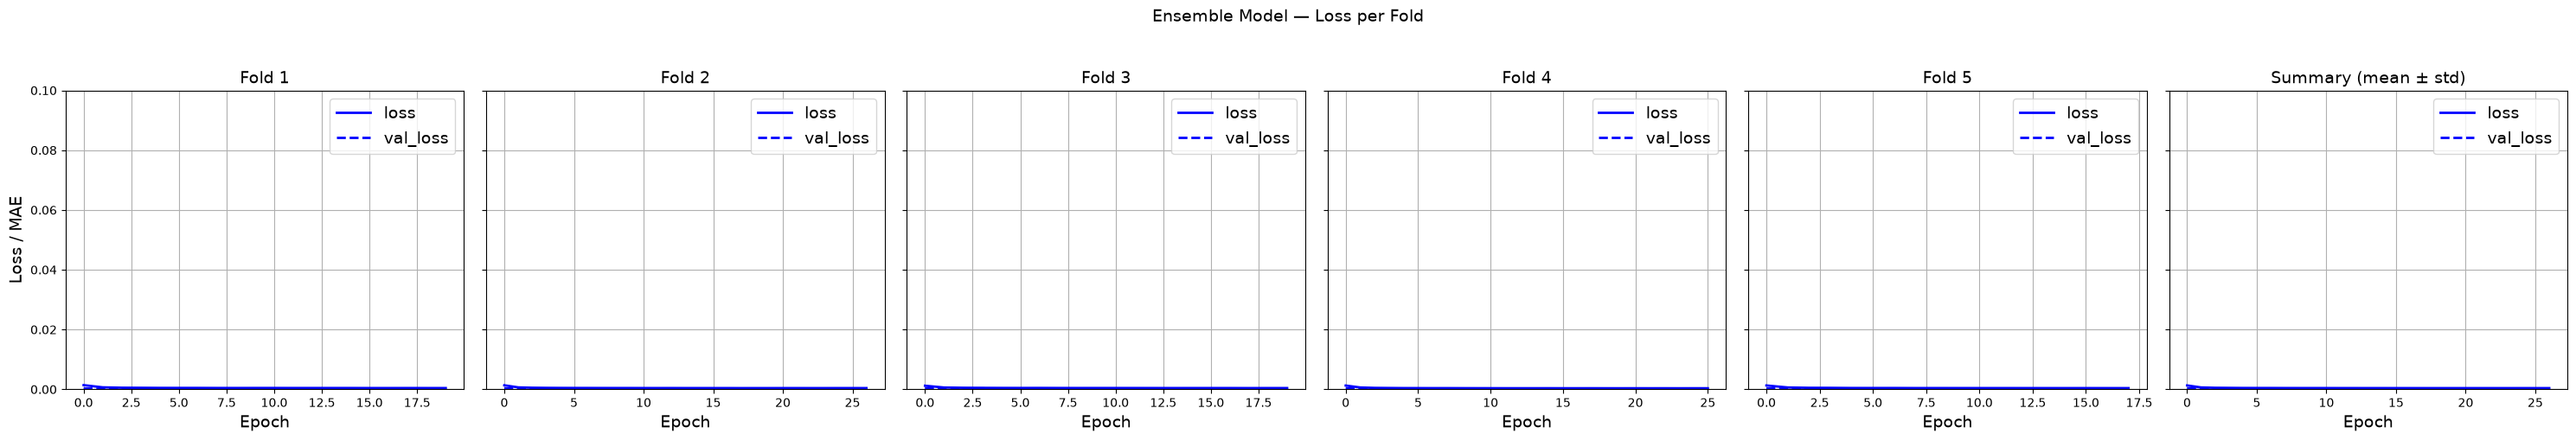

/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3862: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/global/u2/j/jaimerz/UCL/mlpz_cnn_deepset

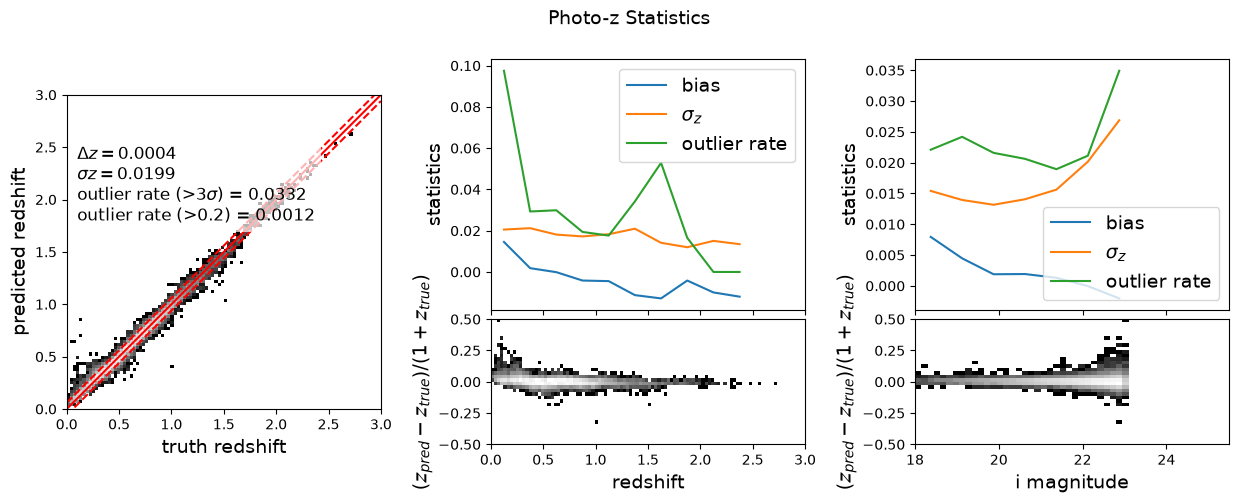

<Figure size 640x480 with 0 Axes>

/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/qp/metrics/array_metrics.py:27: UserWarning: Parameter `variant` has been introduced to replace `midrank`; `midrank` will be removed in SciPy 1.19.0. Specify `variant` to silence this warning. Note that the returned object will no longer be unpackable as a tuple, and `critical_values` will be omitted.
  return stats.anderson_ksamp([p_random_variables, q_random_variables], **kwargs)
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/qp/metrics/array_metrics.py:27: UserWarning: p-value floored: true value smaller than 0.001. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  return stats.anderson_ksamp([p_random_variables, q_random_variables], **kwargs)


outputs/znn_pretrained_popcosmos/pz_challenge_taskset_1_flagship_pz_estimate_1yr.hdf5 checks passed: [1, 2, 3, 4, 5, 6, 7]

========== task set 1: flagship_10yr ==========


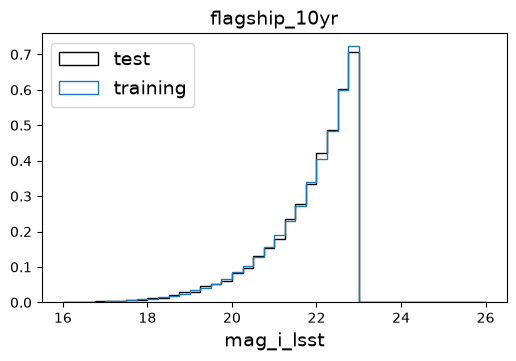


--- Fold 1/5 ---
Epoch 1/100


I0000 00:00:1791448357.624703  877157 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_570246__.37


250/250 - 5s - 18ms/step - loss: 0.0012 - val_loss: 1.6759e-04 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 5.2582e-04 - val_loss: 1.4639e-04 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 3.9034e-04 - val_loss: 8.6819e-05 - learning_rate: 0.0010
Epoch 4/100

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 3.7546e-04 - val_loss: 8.0818e-05 - learning_rate: 0.0010
Epoch 5/100
250/250 - 1s - 3ms/step - loss: 3.4054e-04 - val_loss: 8.1524e-05 - learning_rate: 5.0000e-04
Epoch 6/100
250/250 - 1s - 3ms/step - loss: 3.2623e-04 - val_loss: 7.1658e-05 - learning_rate: 5.0000e-04
Epoch 7/100

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
250/250 - 1s - 3ms/step - loss: 3.3133e-04 - val_loss: 7.4465e-05 - learning_rate: 5.0000e-04
Epoch 8/100
250/250 - 1s - 3ms/step - loss: 3.1941e-04 - val_loss: 7.5335e-05 - learning_rate: 2.5000e-04
Epoch 9/100
250/250 - 1s - 3m

I0000 00:00:1791448378.719906  877157 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_596806__.37


250/250 - 5s - 18ms/step - loss: 0.0011 - val_loss: 1.6405e-04 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 4.6420e-04 - val_loss: 1.0639e-04 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 3.7878e-04 - val_loss: 8.7455e-05 - learning_rate: 0.0010
Epoch 4/100

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 3.5378e-04 - val_loss: 9.1744e-05 - learning_rate: 0.0010
Epoch 5/100
250/250 - 1s - 3ms/step - loss: 3.4349e-04 - val_loss: 7.6350e-05 - learning_rate: 5.0000e-04
Epoch 6/100
250/250 - 1s - 3ms/step - loss: 3.3173e-04 - val_loss: 8.8122e-05 - learning_rate: 5.0000e-04
Epoch 7/100

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
250/250 - 1s - 3ms/step - loss: 3.2762e-04 - val_loss: 7.5717e-05 - learning_rate: 5.0000e-04
Epoch 8/100
250/250 - 1s - 3ms/step - loss: 3.2421e-04 - val_loss: 6.7630e-05 - learning_rate: 2.5000e-04
Epoch 9/100
250/250 - 1s - 3m

...

250/250 - 5s - 19ms/step - loss: 8.4613e-04 - val_loss: 1.8448e-04 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 4.3684e-04 - val_loss: 1.0897e-04 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 3.7455e-04 - val_loss: 1.2336e-04 - learning_rate: 0.0010
Epoch 4/100

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 3.6567e-04 - val_loss: 1.2851e-04 - learning_rate: 0.0010
Epoch 5/100
250/250 - 1s - 3ms/step - loss: 3.4332e-04 - val_loss: 9.1488e-05 - learning_rate: 5.0000e-04
Epoch 6/100
250/250 - 1s - 3ms/step - loss: 3.4694e-04 - val_loss: 9.9920e-05 - learning_rate: 5.0000e-04
Epoch 7/100

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
250/250 - 1s - 3ms/step - loss: 3.4672e-04 - val_loss: 8.8579e-05 - learning_rate: 5.0000e-04
Epoch 8/100
250/250 - 1s - 3ms/step - loss: 3.3312e-04 - val_loss: 8.5004e-05 - learning_rate: 2.5000e-04
Epoch 9/100
250/250 - 1s 

I0000 00:00:1791448419.890456  877158 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_648936__.37


250/250 - 5s - 18ms/step - loss: 0.0010 - val_loss: 1.0692e-04 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 4.5998e-04 - val_loss: 1.0086e-04 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 3.3133e-04 - val_loss: 9.0941e-05 - learning_rate: 0.0010
Epoch 4/100

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 3.1372e-04 - val_loss: 7.5195e-05 - learning_rate: 0.0010
Epoch 5/100
250/250 - 1s - 3ms/step - loss: 2.9108e-04 - val_loss: 6.7706e-05 - learning_rate: 5.0000e-04
Epoch 6/100
250/250 - 1s - 3ms/step - loss: 2.9034e-04 - val_loss: 7.0549e-05 - learning_rate: 5.0000e-04
Epoch 7/100

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
250/250 - 1s - 3ms/step - loss: 2.8205e-04 - val_loss: 6.8440e-05 - learning_rate: 5.0000e-04
Epoch 8/100
250/250 - 1s - 3ms/step - loss: 2.7706e-04 - val_loss: 7.6775e-05 - learning_rate: 2.5000e-04
Epoch 9/100
250/250 - 1s - 3m

I0000 00:00:1791448433.997315  877160 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_665720__.37


250/250 - 5s - 19ms/step - loss: 0.0010 - val_loss: 1.0602e-04 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 4.7375e-04 - val_loss: 1.0468e-04 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 3.7865e-04 - val_loss: 8.3217e-05 - learning_rate: 0.0010
Epoch 4/100

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 3.4850e-04 - val_loss: 9.0553e-05 - learning_rate: 0.0010
Epoch 5/100
250/250 - 1s - 3ms/step - loss: 3.2575e-04 - val_loss: 7.2728e-05 - learning_rate: 5.0000e-04
Epoch 6/100
250/250 - 1s - 3ms/step - loss: 3.2762e-04 - val_loss: 8.4997e-05 - learning_rate: 5.0000e-04
Epoch 7/100

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
250/250 - 1s - 3ms/step - loss: 3.2644e-04 - val_loss: 7.5929e-05 - learning_rate: 5.0000e-04
Epoch 8/100
250/250 - 1s - 3ms/step - loss: 3.1722e-04 - val_loss: 6.0546e-05 - learning_rate: 2.5000e-04
Epoch 9/100
250/250 - 1s - 3m

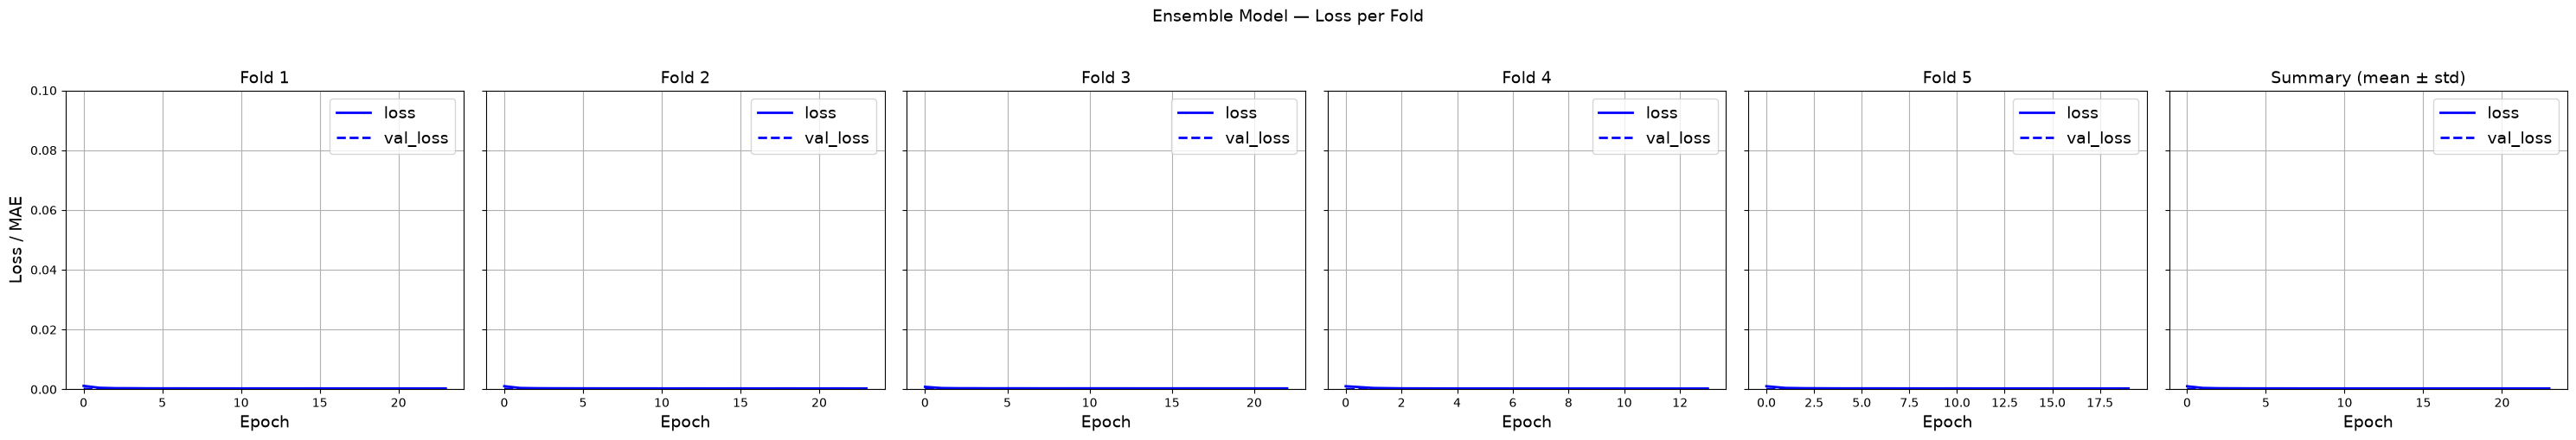

/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3862: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/global/u2/j/jaimerz/UCL/mlpz_cnn_deepset

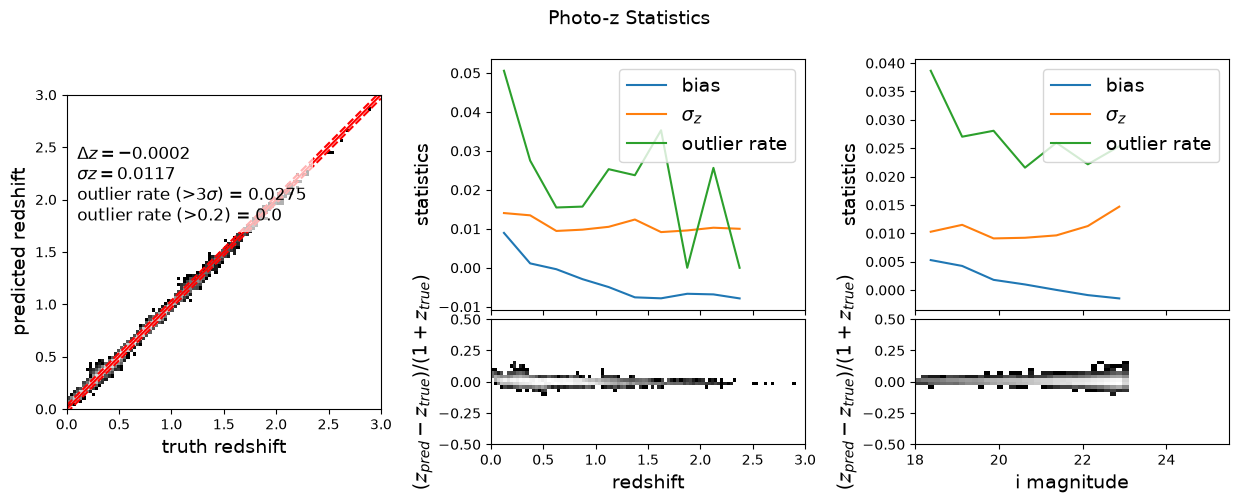

<Figure size 640x480 with 0 Axes>

/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/qp/metrics/array_metrics.py:27: UserWarning: Parameter `variant` has been introduced to replace `midrank`; `midrank` will be removed in SciPy 1.19.0. Specify `variant` to silence this warning. Note that the returned object will no longer be unpackable as a tuple, and `critical_values` will be omitted.
  return stats.anderson_ksamp([p_random_variables, q_random_variables], **kwargs)
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/qp/metrics/array_metrics.py:27: UserWarning: p-value floored: true value smaller than 0.001. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  return stats.anderson_ksamp([p_random_variables, q_random_variables], **kwargs)


outputs/znn_pretrained_popcosmos/pz_challenge_taskset_1_flagship_pz_estimate_10yr.hdf5 checks passed: [1, 2, 3, 4, 5, 6, 7]


In [10]:
results = {}

for SIM in SIMS:
    for SCENARIO in SCENARIOS:
        config = f"{SIM}_{SCENARIO}"
        print(f"\n========== task set {TASKSET}: {config} ==========")

        train_file = os.path.join(DATA_DIR, f"pz_challenge_taskset_{TASKSET}_{SIM}_training_{SCENARIO}.hdf5")
        test_file = os.path.join(DATA_DIR, f"pz_challenge_taskset_{TASKSET}_{SIM}_test_{SCENARIO}.hdf5")
        train = znn.read_catalog(train_file)
        test = znn.read_catalog(test_file)
        z_ref, subsets = reference_redshifts(train)

        # how representative is the training set of the test set?
        bins = np.linspace(16, 26, 41)
        plt.figure(figsize=[6, 3.5])
        plt.hist(test["mag_i_lsst"], bins, density=True, histtype="step", color="k", label="test")
        plt.hist(train["mag_i_lsst"], bins, density=True, histtype="step", label="training")
        plt.xlabel("mag_i_lsst")
        plt.title(config)
        plt.legend()
        plt.show()

        X, _ = znn.catalog_to_XY(train, BANDS, REF_BAND, FEATURE_CONFIG)
        rng = np.random.default_rng(NOISE_SEED)

        idx_fit, idx_val = train_test_split(np.arange(len(train)), test_size=VAL_FRAC, random_state=SEED)
        trained_models, histories = znn.train_ensembles(
            znn.build_model, X[idx_fit], z_ref[idx_fit], N_SPLITS=N_SPLITS, EPOCHS=EPOCHS, random_state=SEED, pretraining=PRETRAINING
        )
        znn.plot_ensemble_losses(histories, ylim=(0, 0.1))

        val = train.iloc[idx_val]
        for name, mask in subsets.items():
            m = mask[idx_val]
            results[(config, name)] = evaluate(
                trained_models, val[m], z_ref[idx_val][m], rng, title=f"{config}: {name}"
            )

        # submission files: subtask 1 p(z) and subtask 2 model
        estimate_file = os.path.join(OUT_DIR, f"pz_challenge_taskset_{TASKSET}_{SIM}_pz_estimate_{SCENARIO}.hdf5")
        model_file = os.path.join(OUT_DIR, f"pz_challenge_taskset_{TASKSET}_{SIM}_pz_model_{SCENARIO}.pkl")

        pz_test = predict(trained_models, test, rng)
        pz_test.write_to(estimate_file)
        znn.save_ensemble_file(model_file, trained_models, BANDS, REF_BAND, FEATURE_CONFIG)

        checks = submit_utils.check_pz_submission_file(estimate_file, test_file)
        print(estimate_file, "checks passed:", checks)
        assert checks == [1, 2, 3, 4, 5, 6, 7], "submission file failed the challenge format checks"

## Summary

Metric values and points against the challenge scoring tiers (`pz_data_challenge.scoring.metric_dict`: three nested ranges per metric, one point per range), per configuration and held-out subset.

In [11]:
table = pd.DataFrame(results).T
table.index.names = ["configuration", "subset"]

points = pd.DataFrame({key: tier_points(values) for key, values in results.items()}).T
points["total"] = points.sum(axis=1)
points.index.names = ["configuration", "subset"]
n_max = sum(len(r) for r in scoring.metric_dict.values())

print("metric values")
print(table.round(4).to_string())
print(f"\npoints (out of 3 per metric, {n_max} in total)")
print(points.to_string())

metric values
                          mean     std  abs_outlier_rate      ks      CvM     ksamp  outlier  pit_outlier_direct
configuration subset                                                                                            
cardinal_1yr  held-out  0.0018  0.0178            0.0016  0.0871  60.0842  274.2407   0.0103              0.0102
cardinal_10yr held-out  0.0007  0.0113            0.0002  0.0667  33.3644  176.7558   0.0025              0.0080
flagship_1yr  held-out  0.0004  0.0199            0.0012  0.0766  49.8812  286.5411   0.0093              0.0140
flagship_10yr held-out -0.0002  0.0117            0.0000  0.0847  67.6429  395.0752   0.0297              0.0224

points (out of 3 per metric, 21 in total)
                        mean  std  abs_outlier_rate  CvM  outlier  ks  ksamp  total
configuration subset                                                               
cardinal_1yr  held-out     3    3                 3    3        3   3      3     21
cardinal_10yr